# 03 — Exploratory Data Analysis (EDA)

Comprehensive visual analysis of BigBasket product catalog covering:
1. Category & Sub-Category Distribution
2. Pricing & Discount Analysis
3. Rating Analysis
4. Brand Performance
5. Cross-Segment Insights

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='viridis', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv('../data/processed/bigbasket_cleaned.csv')
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Matplotlib is building the font cache; this may take a moment.


Loaded: 27,200 rows × 15 columns


,product,category,sub_category,brand,sale_price,market_price,type,rating,description,is_price_anomaly,discount_amount,discount_pct,price_segment,is_discounted,rating_segment
0,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...,False,0.0,0.00,Mid-range,False,High
1,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ...",False,0.0,0.00,Mid-range,False,Low
2,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m...",False,131.0,52.40,Mid-range,True,Medium
3,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...,False,27.0,15.34,Mid-range,True,Medium
4,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...,False,0.0,0.00,Mid-range,False,High


---
## 1. Category & Sub-Category Distribution

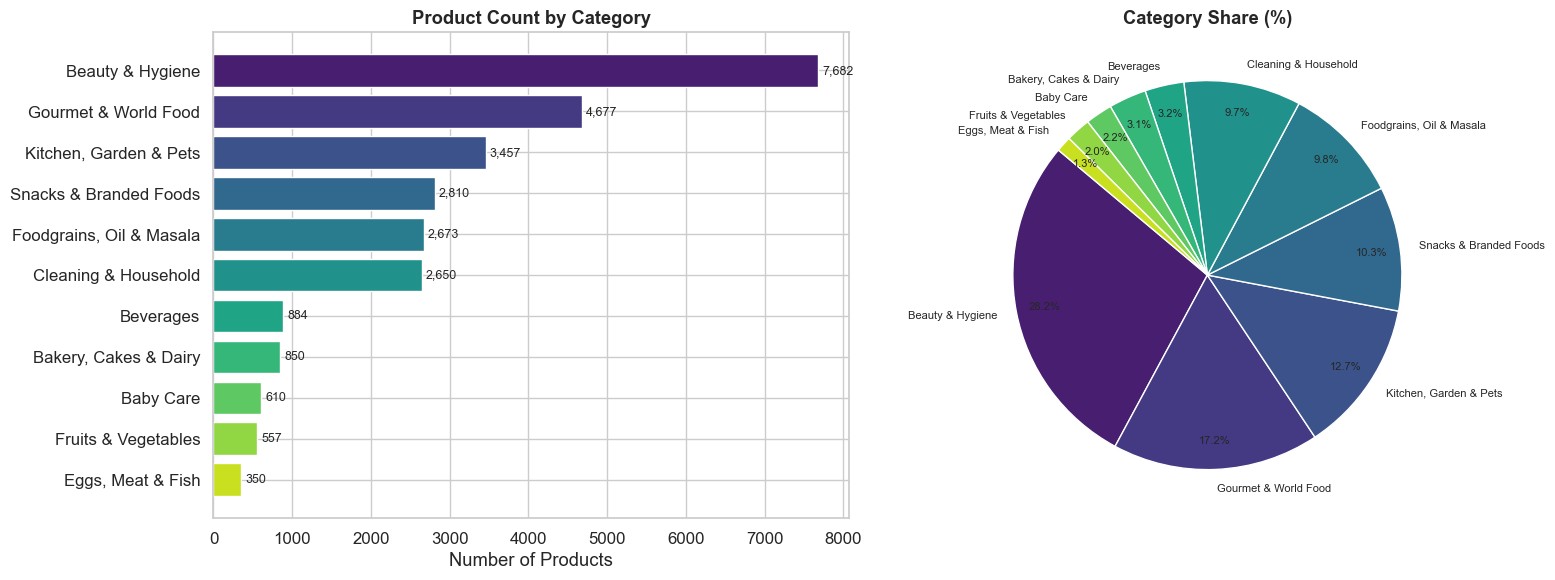

In [ ]:
# Product count by category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_counts = df['category'].value_counts()
colors = sns.color_palette('viridis', len(cat_counts))

# Bar chart
ax1 = axes[0]
bars = ax1.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors[::-1], edgecolor='white')
ax1.set_title('Product Count by Category')
ax1.set_xlabel('Number of Products')
for bar, val in zip(bars, cat_counts.values[::-1]):
    ax1.text(val + 50, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)

# Pie chart
ax2 = axes[1]
ax2.pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%', colors=colors, startangle=140,
        textprops={'fontsize': 8}, pctdistance=0.85)
ax2.set_title('Category Share (%)')

plt.tight_layout()
plt.savefig('../data/processed/01_category_distribution.png', bbox_inches='tight')
plt.show()

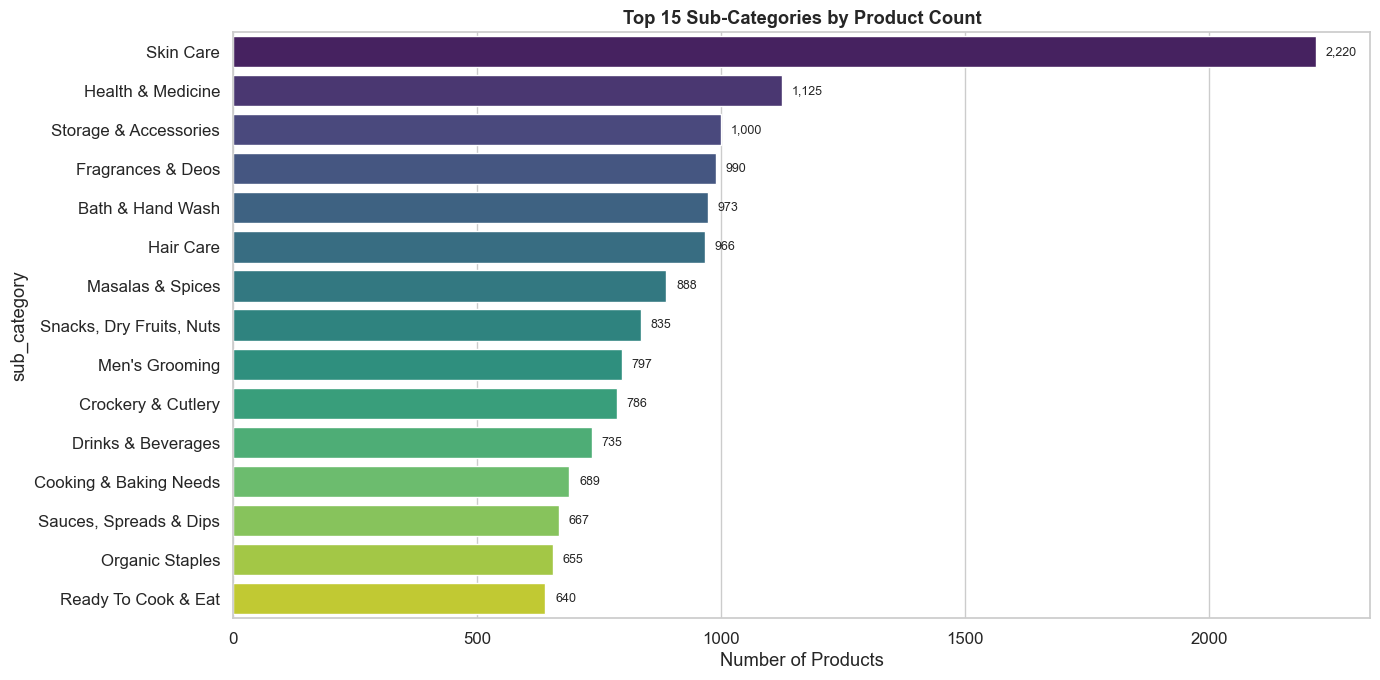

In [ ]:
# Top 15 sub-categories
fig, ax = plt.subplots(figsize=(14, 7))
top_sub = df['sub_category'].value_counts().head(15)
sns.barplot(x=top_sub.values, y=top_sub.index, palette='viridis', ax=ax, edgecolor='white')
ax.set_title('Top 15 Sub-Categories by Product Count')
ax.set_xlabel('Number of Products')
for i, val in enumerate(top_sub.values):
    ax.text(val + 20, i, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/02_top_subcategories.png', bbox_inches='tight')
plt.show()

---
## 2. Pricing Analysis

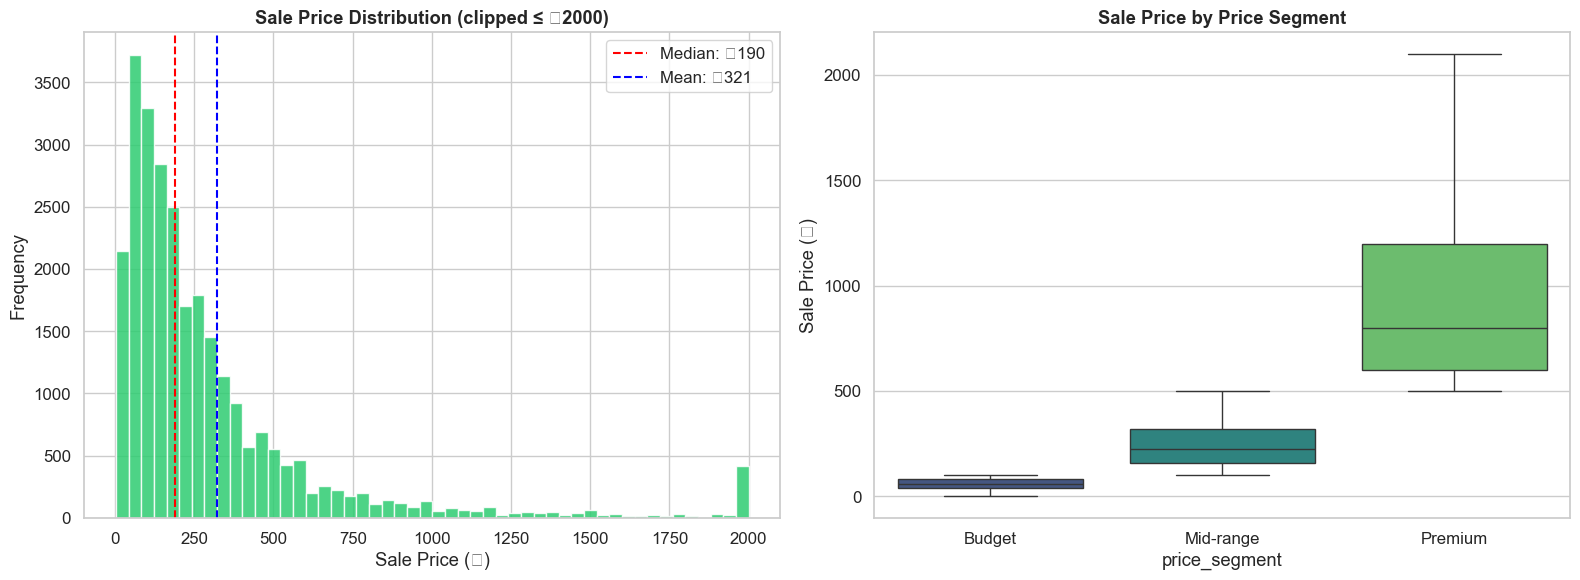

In [4]:
# Sale Price Distribution (clipped at 2000 for readability)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
df['sale_price'].clip(upper=2000).hist(bins=50, ax=ax1, color='#2ecc71', edgecolor='white', alpha=0.85)
ax1.axvline(df['sale_price'].median(), color='red', linestyle='--', label=f'Median: ₹{df["sale_price"].median():.0f}')
ax1.axvline(df['sale_price'].mean(), color='blue', linestyle='--', label=f'Mean: ₹{df["sale_price"].mean():.0f}')
ax1.set_title('Sale Price Distribution (clipped ≤ ₹2000)')
ax1.set_xlabel('Sale Price (₹)')
ax1.set_ylabel('Frequency')
ax1.legend()

# Box plot by price segment
ax2 = axes[1]
order = ['Budget', 'Mid-range', 'Premium']
sns.boxplot(data=df, x='price_segment', y='sale_price', order=order, palette='viridis', ax=ax2, showfliers=False)
ax2.set_title('Sale Price by Price Segment')
ax2.set_ylabel('Sale Price (₹)')

plt.tight_layout()
plt.savefig('../data/processed/03_price_distribution.png', bbox_inches='tight')
plt.show()

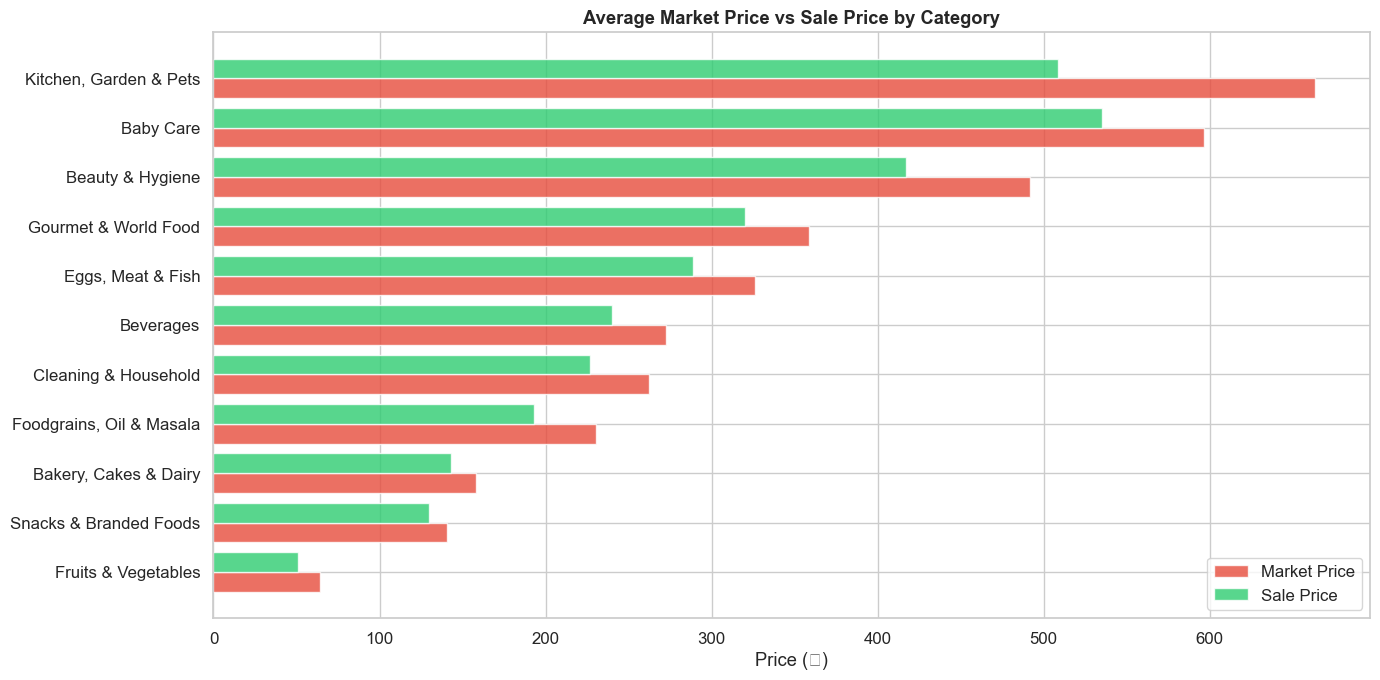

In [ ]:
# Average Sale Price vs Market Price by Category
fig, ax = plt.subplots(figsize=(14, 7))
cat_prices = df.groupby('category')[['sale_price', 'market_price']].mean().sort_values('market_price', ascending=True)

y_pos = range(len(cat_prices))
ax.barh([y - 0.2 for y in y_pos], cat_prices['market_price'], height=0.4, label='Market Price', color='#e74c3c', alpha=0.8)
ax.barh([y + 0.2 for y in y_pos], cat_prices['sale_price'], height=0.4, label='Sale Price', color='#2ecc71', alpha=0.8)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(cat_prices.index)
ax.set_title('Average Market Price vs Sale Price by Category')
ax.set_xlabel('Price (₹)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../data/processed/04_price_by_category.png', bbox_inches='tight')
plt.show()

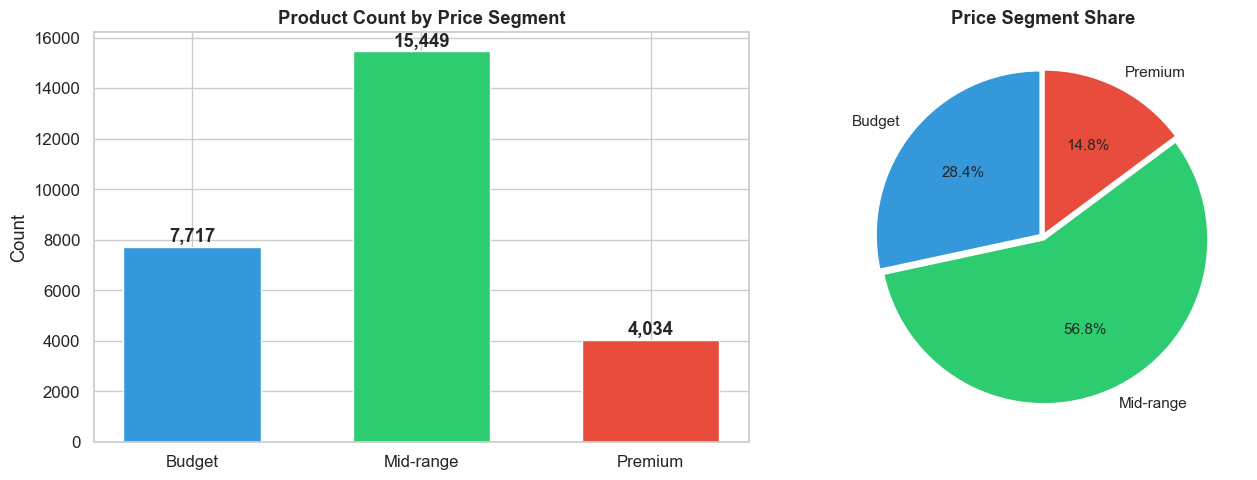

In [6]:
# Price Segment Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = df['price_segment'].value_counts().reindex(['Budget','Mid-range','Premium'])
colors_seg = ['#3498db', '#2ecc71', '#e74c3c']

axes[0].bar(seg_counts.index, seg_counts.values, color=colors_seg, edgecolor='white', width=0.6)
for i, val in enumerate(seg_counts.values):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold')
axes[0].set_title('Product Count by Price Segment')
axes[0].set_ylabel('Count')

axes[1].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%', colors=colors_seg, startangle=90,
           textprops={'fontsize':11}, explode=[0.02]*3)
axes[1].set_title('Price Segment Share')

plt.tight_layout()
plt.savefig('../data/processed/05_price_segments.png', bbox_inches='tight')
plt.show()

---
## 3. Discount Analysis

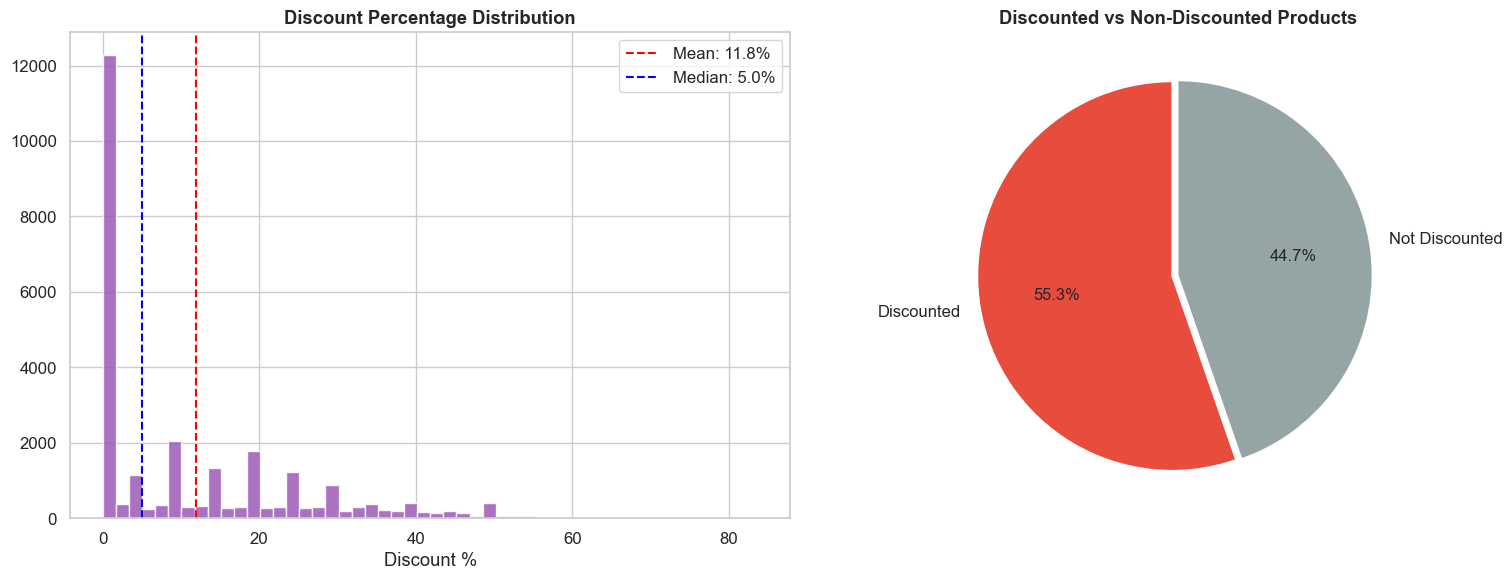

In [7]:
# Discount Percentage Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
df['discount_pct'].hist(bins=50, ax=axes[0], color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0].axvline(df['discount_pct'].mean(), color='red', linestyle='--', label=f'Mean: {df["discount_pct"].mean():.1f}%')
axes[0].axvline(df['discount_pct'].median(), color='blue', linestyle='--', label=f'Median: {df["discount_pct"].median():.1f}%')
axes[0].set_title('Discount Percentage Distribution')
axes[0].set_xlabel('Discount %')
axes[0].legend()

# Discounted vs Not
disc_counts = df['is_discounted'].value_counts()
axes[1].pie(disc_counts.values, labels=['Discounted', 'Not Discounted'], autopct='%1.1f%%',
           colors=['#e74c3c', '#95a5a6'], startangle=90, textprops={'fontsize':12}, explode=[0.03, 0])
axes[1].set_title('Discounted vs Non-Discounted Products')

plt.tight_layout()
plt.savefig('../data/processed/06_discount_distribution.png', bbox_inches='tight')
plt.show()

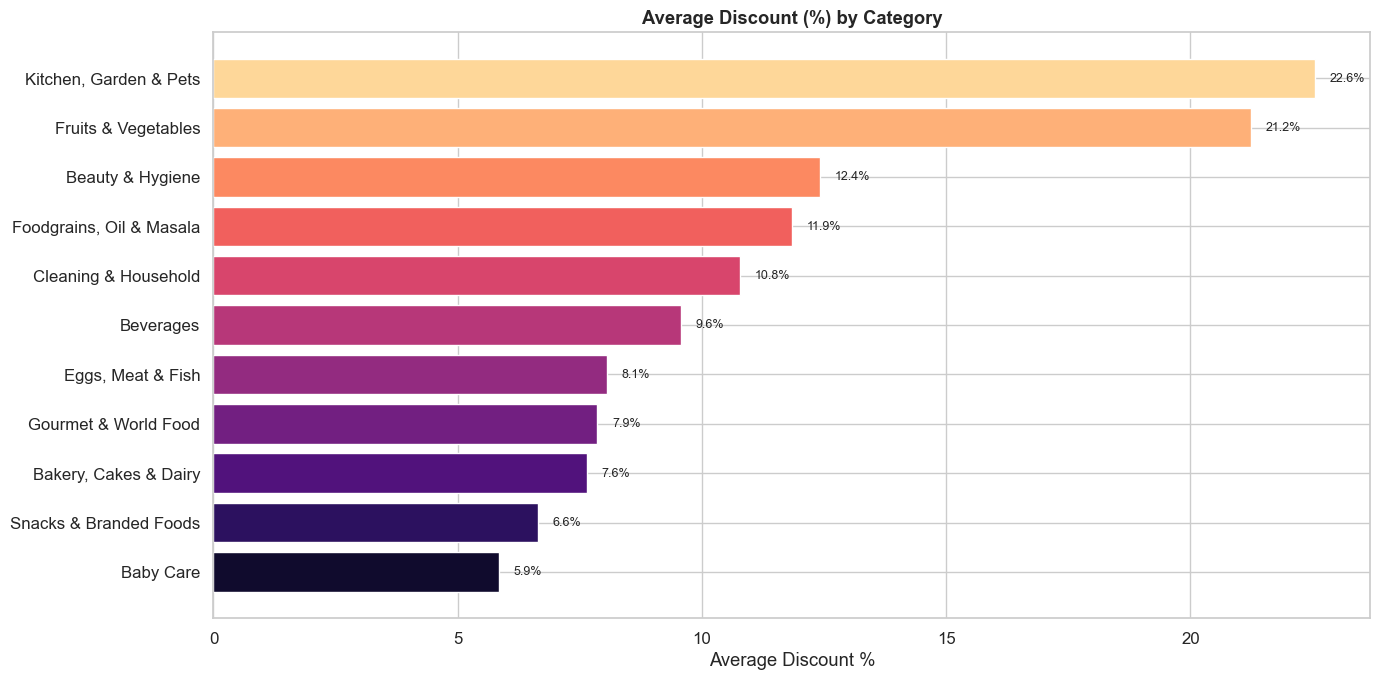

In [8]:
# Average Discount % by Category
fig, ax = plt.subplots(figsize=(14, 7))
cat_disc = df.groupby('category')['discount_pct'].mean().sort_values(ascending=True)
bars = ax.barh(cat_disc.index, cat_disc.values, color=sns.color_palette('magma', len(cat_disc)), edgecolor='white')
ax.set_title('Average Discount (%) by Category')
ax.set_xlabel('Average Discount %')
for bar, val in zip(bars, cat_disc.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/07_discount_by_category.png', bbox_inches='tight')
plt.show()

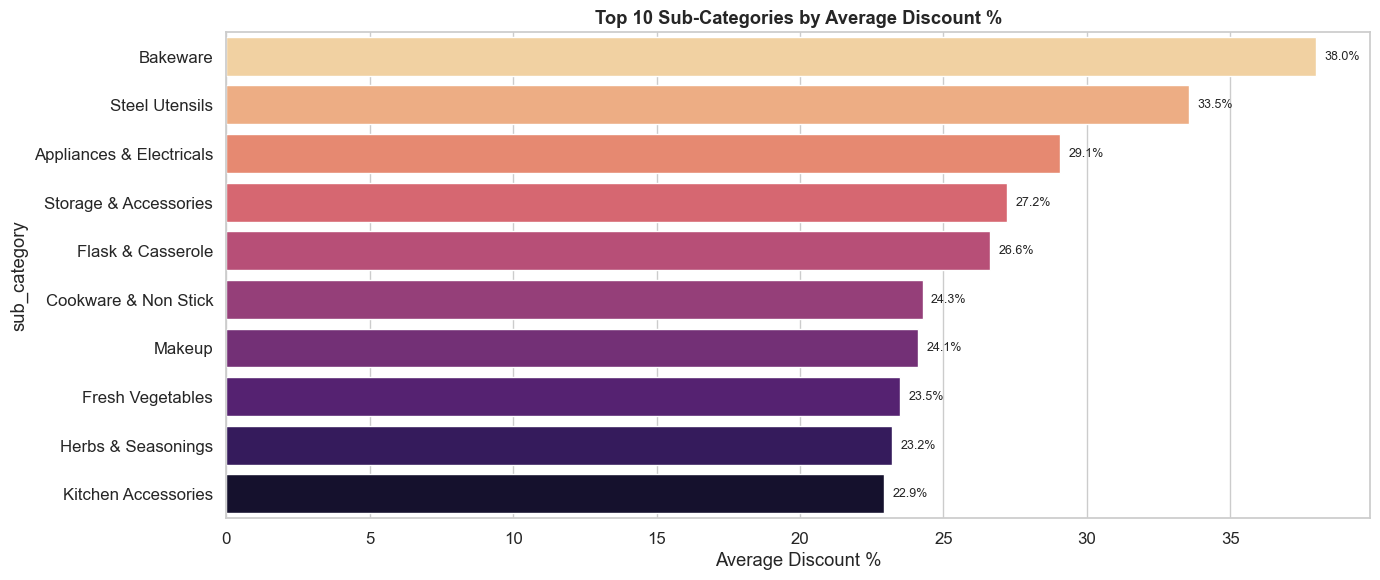

In [9]:
# Top 10 most discounted sub-categories
fig, ax = plt.subplots(figsize=(14, 6))
sub_disc = df.groupby('sub_category')['discount_pct'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=sub_disc.values, y=sub_disc.index, palette='magma_r', ax=ax, edgecolor='white')
ax.set_title('Top 10 Sub-Categories by Average Discount %')
ax.set_xlabel('Average Discount %')
for i, val in enumerate(sub_disc.values):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/08_top_discounted_subcats.png', bbox_inches='tight')
plt.show()

---
## 4. Rating Analysis

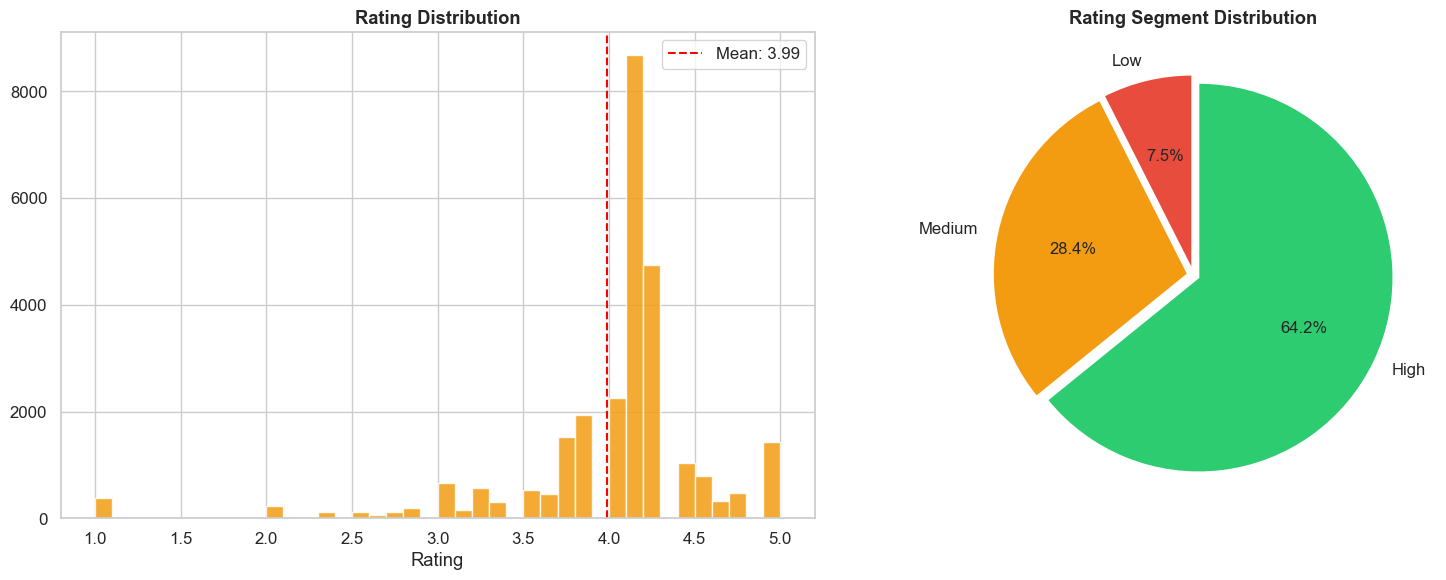

In [11]:
# Rating Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['rating'].hist(bins=40, ax=axes[0], color='#f39c12', edgecolor='white', alpha=0.85)
axes[0].axvline(df['rating'].mean(), color='red', linestyle='--', label=f'Mean: {df["rating"].mean():.2f}')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].legend()

# Rating segment pie
seg = df['rating_segment'].value_counts().reindex(['Low','Medium','High'])
axes[1].pie(seg.values, labels=seg.index, autopct='%1.1f%%',
           colors=['#e74c3c','#f39c12','#2ecc71'], startangle=90, textprops={'fontsize':12}, explode=[0.03]*3)
axes[1].set_title('Rating Segment Distribution')

plt.tight_layout()
plt.savefig('../data/processed/09_rating_distribution.png', bbox_inches='tight')
plt.show()

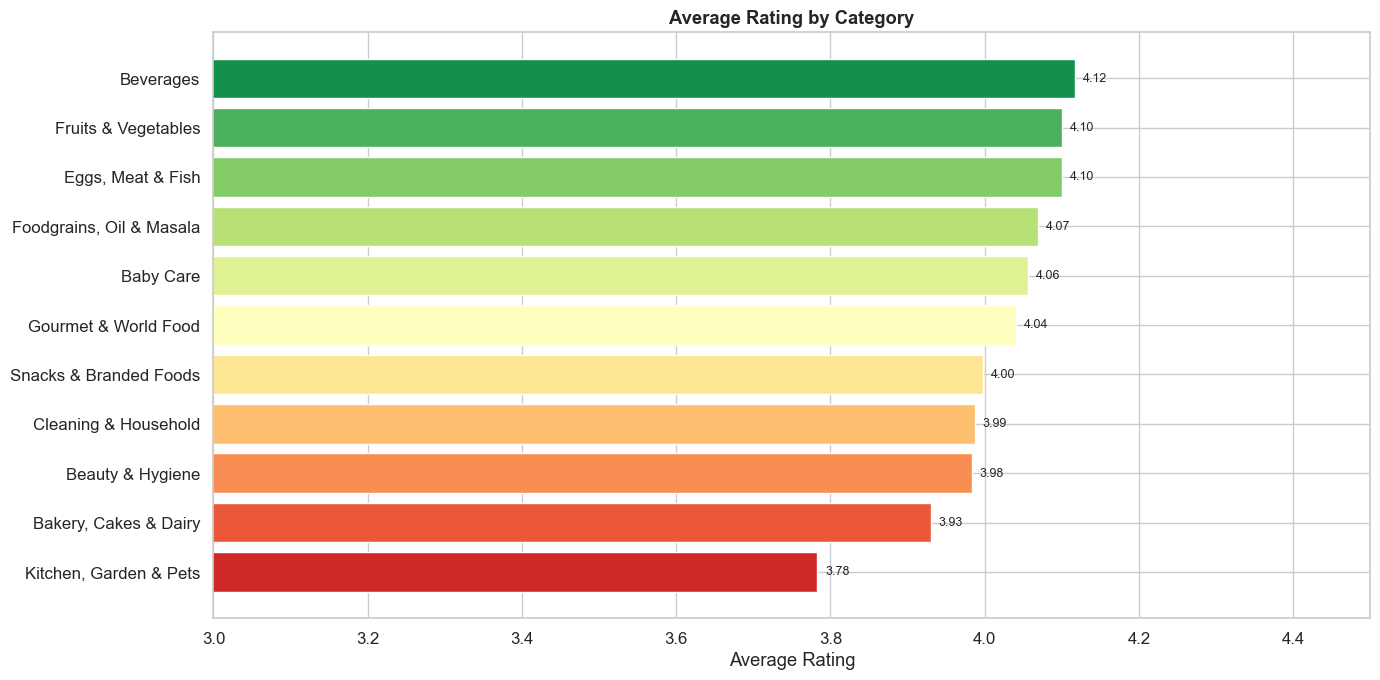

In [12]:
# Average Rating by Category
fig, ax = plt.subplots(figsize=(14, 7))
cat_rating = df.groupby('category')['rating'].mean().sort_values(ascending=True)
colors_r = sns.color_palette('RdYlGn', len(cat_rating))
bars = ax.barh(cat_rating.index, cat_rating.values, color=colors_r, edgecolor='white')
ax.set_title('Average Rating by Category')
ax.set_xlabel('Average Rating')
ax.set_xlim(3, 4.5)
for bar, val in zip(bars, cat_rating.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/10_rating_by_category.png', bbox_inches='tight')
plt.show()

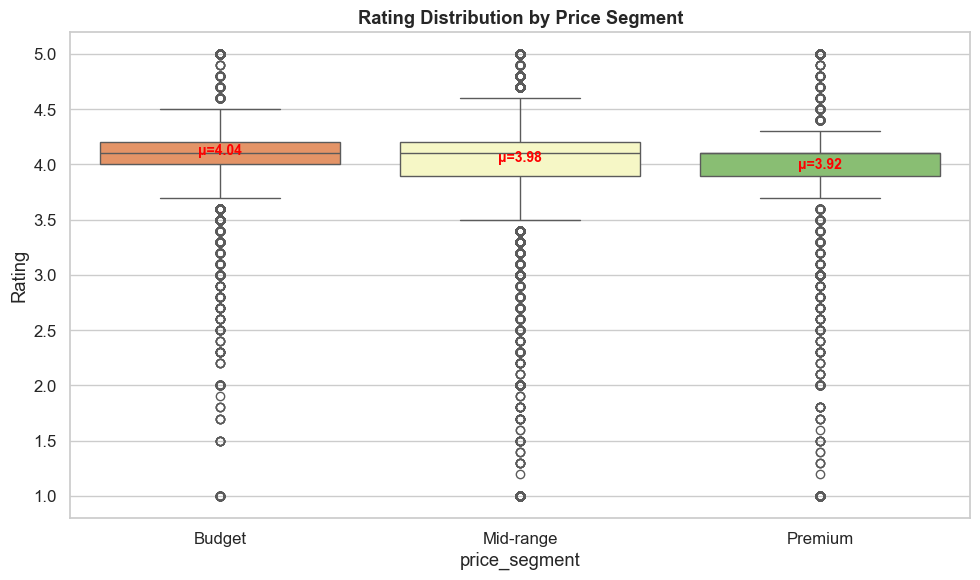

In [13]:
# Rating vs Price Segment (Box plot)
fig, ax = plt.subplots(figsize=(10, 6))
order = ['Budget', 'Mid-range', 'Premium']
sns.boxplot(data=df, x='price_segment', y='rating', order=order, palette='RdYlGn', ax=ax)
ax.set_title('Rating Distribution by Price Segment')
ax.set_ylabel('Rating')

# Add means as text
for i, seg in enumerate(order):
    mean_val = df[df['price_segment']==seg]['rating'].mean()
    ax.text(i, mean_val + 0.05, f'μ={mean_val:.2f}', ha='center', fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/11_rating_by_price_segment.png', bbox_inches='tight')
plt.show()

---
## 5. Brand Performance

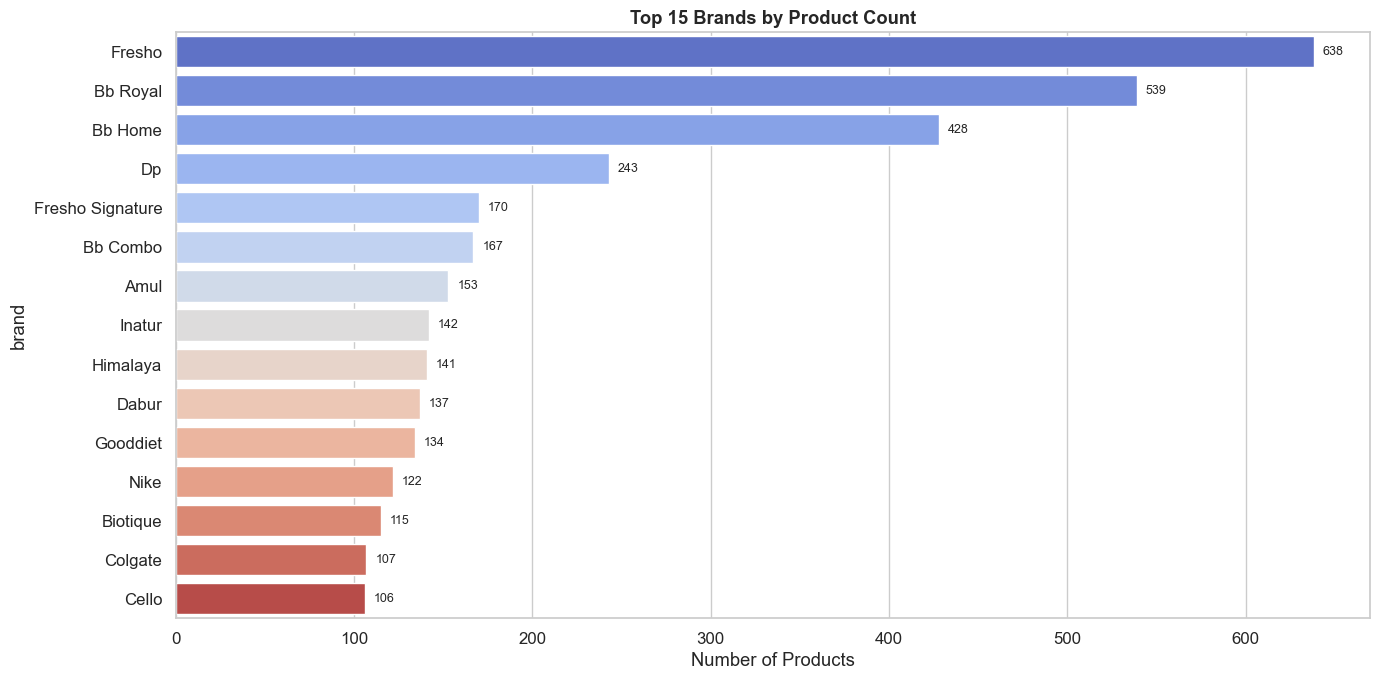

In [14]:
# Top 15 Brands by Product Count
fig, ax = plt.subplots(figsize=(14, 7))
top_brands = df['brand'].value_counts().head(15)
sns.barplot(x=top_brands.values, y=top_brands.index, palette='coolwarm', ax=ax, edgecolor='white')
ax.set_title('Top 15 Brands by Product Count')
ax.set_xlabel('Number of Products')
for i, val in enumerate(top_brands.values):
    ax.text(val + 5, i, f'{val}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/12_top_brands.png', bbox_inches='tight')
plt.show()

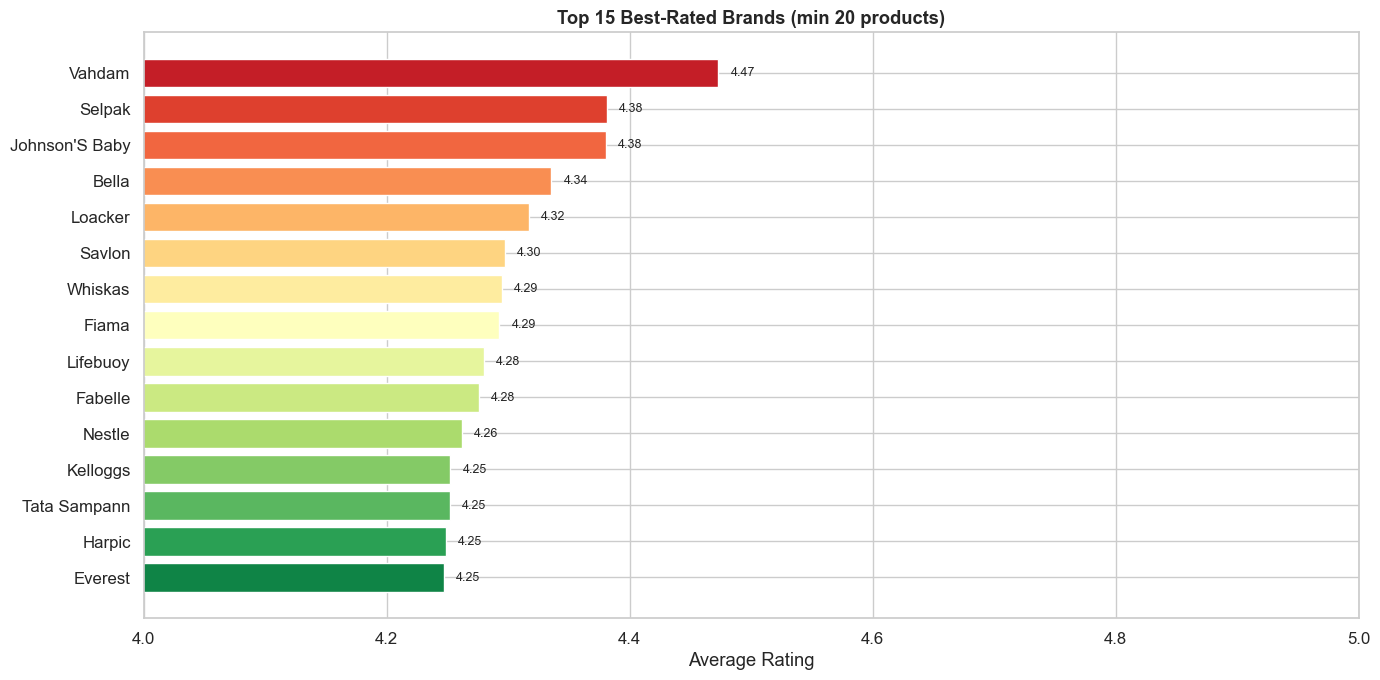

In [15]:
# Top 15 Brands by Avg Rating (min 20 products)
fig, ax = plt.subplots(figsize=(14, 7))
brand_stats = df.groupby('brand').agg(avg_rating=('rating','mean'), count=('rating','count'))
top_rated = brand_stats[brand_stats['count'] >= 20].nlargest(15, 'avg_rating')

bars = ax.barh(top_rated.index[::-1], top_rated['avg_rating'].values[::-1],
              color=sns.color_palette('RdYlGn', 15)[::-1], edgecolor='white')
ax.set_title('Top 15 Best-Rated Brands (min 20 products)')
ax.set_xlabel('Average Rating')
ax.set_xlim(4, 5)
for bar, val in zip(bars, top_rated['avg_rating'].values[::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/13_top_rated_brands.png', bbox_inches='tight')
plt.show()

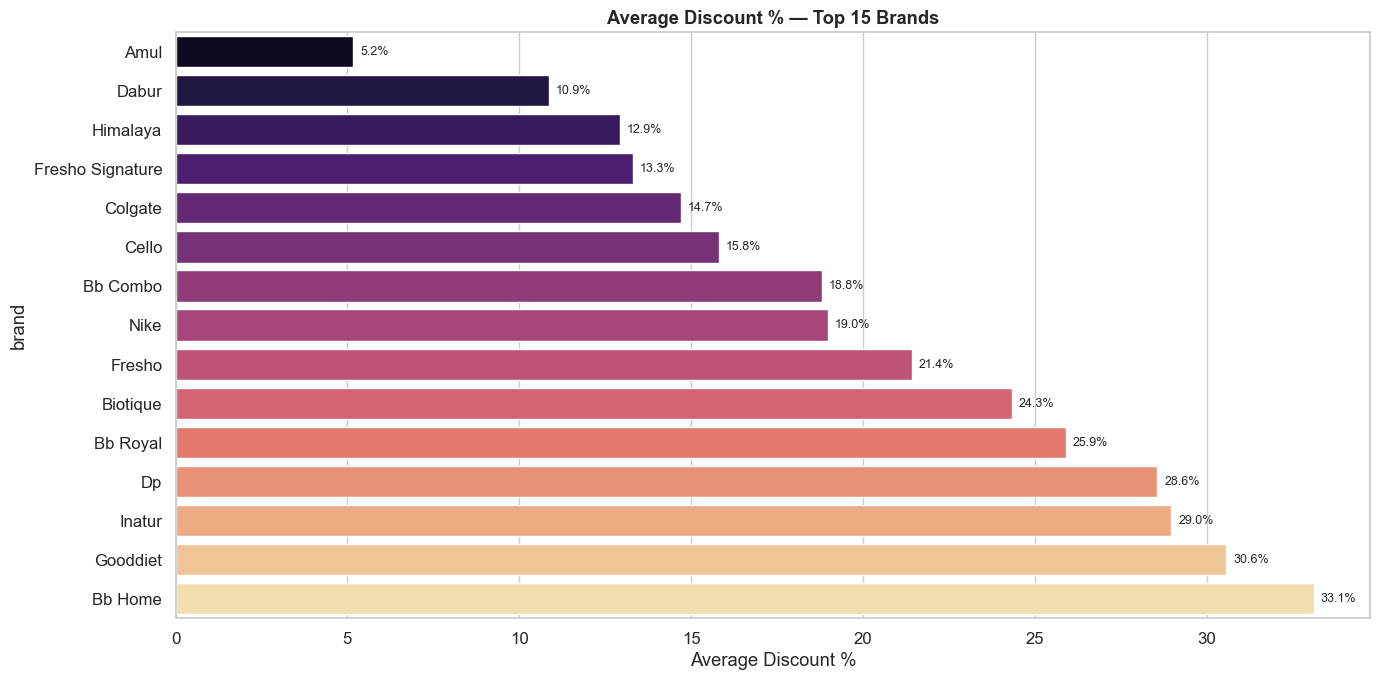

In [16]:
# Average Discount by Top 15 Brands
fig, ax = plt.subplots(figsize=(14, 7))
top15 = df['brand'].value_counts().head(15).index
brand_disc = df[df['brand'].isin(top15)].groupby('brand')['discount_pct'].mean().sort_values(ascending=True)
sns.barplot(x=brand_disc.values, y=brand_disc.index, palette='magma', ax=ax, edgecolor='white')
ax.set_title('Average Discount % — Top 15 Brands')
ax.set_xlabel('Average Discount %')
for i, val in enumerate(brand_disc.values):
    ax.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/14_discount_by_brand.png', bbox_inches='tight')
plt.show()

---
## 6. Cross-Segment & Correlation Insights

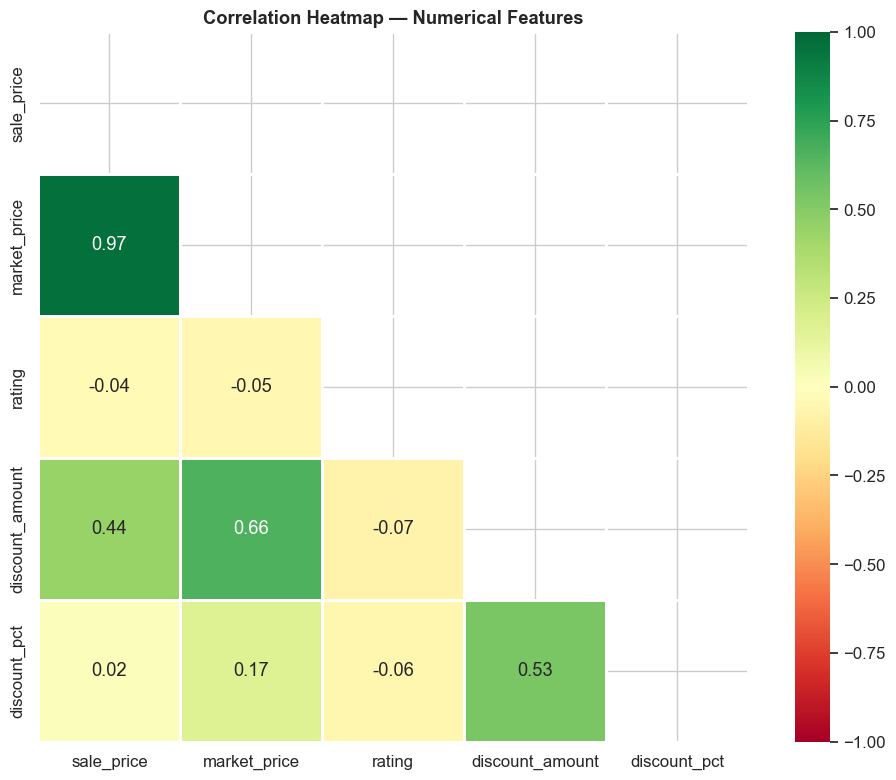

In [17]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
num_cols = ['sale_price', 'market_price', 'rating', 'discount_amount', 'discount_pct']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
           square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.savefig('../data/processed/15_correlation_heatmap.png', bbox_inches='tight')
plt.show()

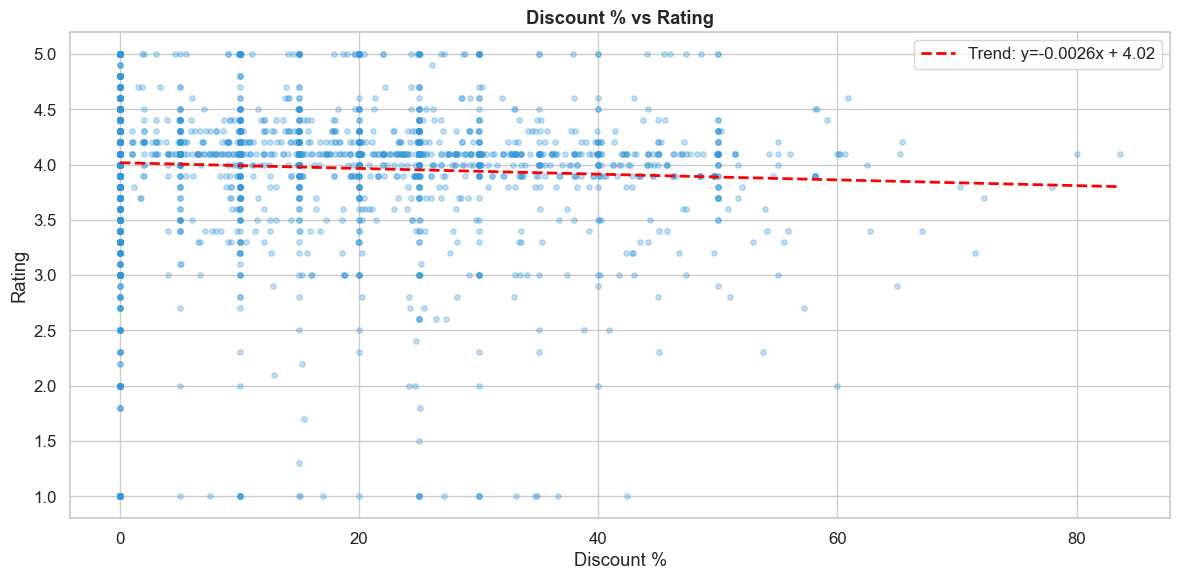

In [18]:
# Discount % vs Rating — Scatter with trend
fig, ax = plt.subplots(figsize=(12, 6))
sample = df.sample(3000, random_state=42)
ax.scatter(sample['discount_pct'], sample['rating'], alpha=0.3, s=15, c='#3498db')
z = np.polyfit(df['discount_pct'], df['rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['discount_pct'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend: y={z[0]:.4f}x + {z[1]:.2f}')
ax.set_title('Discount % vs Rating')
ax.set_xlabel('Discount %')
ax.set_ylabel('Rating')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/16_discount_vs_rating.png', bbox_inches='tight')
plt.show()

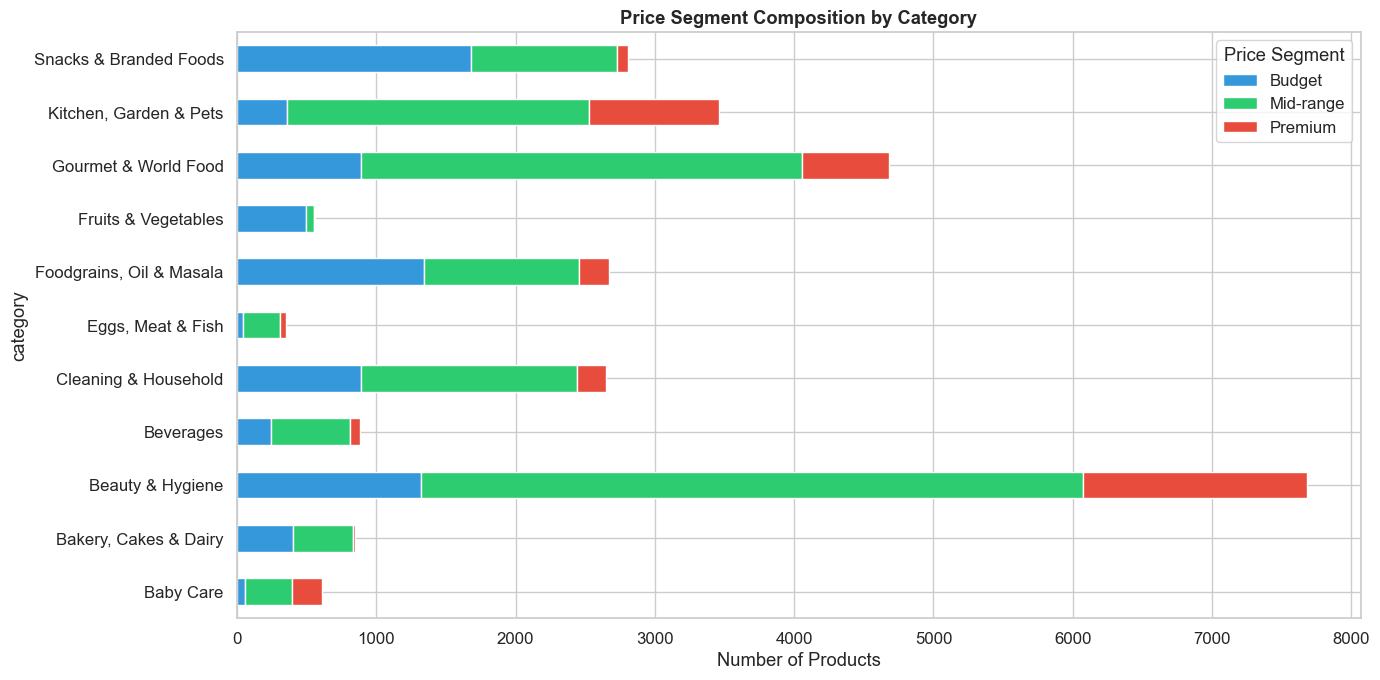

In [19]:
# Category × Price Segment — Stacked count
fig, ax = plt.subplots(figsize=(14, 7))
ct = pd.crosstab(df['category'], df['price_segment'])
ct = ct.reindex(columns=['Budget','Mid-range','Premium'])
ct.plot(kind='barh', stacked=True, ax=ax, color=['#3498db','#2ecc71','#e74c3c'], edgecolor='white')
ax.set_title('Price Segment Composition by Category')
ax.set_xlabel('Number of Products')
ax.legend(title='Price Segment')
plt.tight_layout()
plt.savefig('../data/processed/17_category_price_segment.png', bbox_inches='tight')
plt.show()

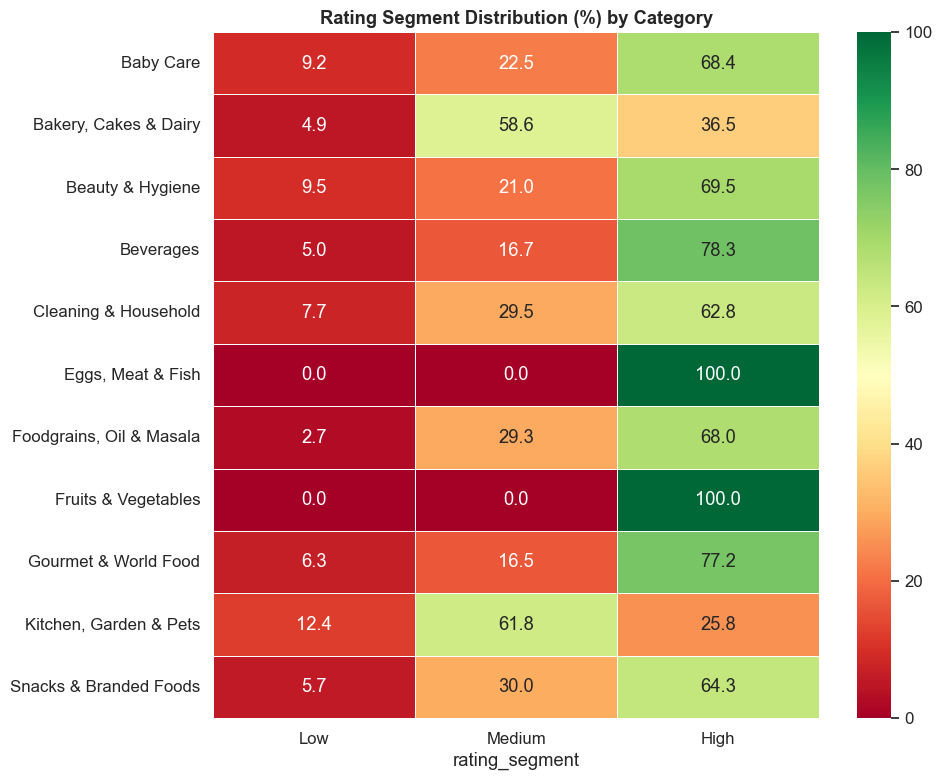

In [20]:
# Category × Rating Segment heatmap
fig, ax = plt.subplots(figsize=(10, 8))
ct2 = pd.crosstab(df['category'], df['rating_segment'], normalize='index') * 100
ct2 = ct2.reindex(columns=['Low','Medium','High'])
sns.heatmap(ct2, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax, linewidths=0.5)
ax.set_title('Rating Segment Distribution (%) by Category')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../data/processed/18_category_rating_heatmap.png', bbox_inches='tight')
plt.show()

---
## 7. Key EDA Takeaways

1. **Beauty & Hygiene dominates** the catalog (~28.5%) — heavy category imbalance
2. **Mid-range products** (₹100–500) are the largest segment at ~56.8%
3. **55.3% products are discounted**, with avg discount ~11.8% and max ~84%
4. **Most products rated High (>4)** — ~64%, with only ~7.5% rated Low
5. **Fresho, bb Royal, BB Home** are BigBasket's own brands dominating the catalog
6. **Premium products don't necessarily have higher ratings** — price ≠ satisfaction
7. **Discount % has very weak negative correlation with rating** — heavy discounts don't boost ratings
8. **sale_price and market_price are highly correlated** (>0.95) as expected